In [1]:
import pandas as pd
import numpy as np

# 1. Load the original dataset
df = pd.read_csv("AB_NYC_2019.csv")

# -----------------------------------
# 2. Text Normalization 
# -----------------------------------
# Standardizing text to lowercase to ensure consistency and improve grouping
df['name'] = df['name'].str.lower()
df['host_name'] = df['host_name'].str.lower()
df['neighbourhood'] = df['neighbourhood'].str.lower()

# -----------------------------------
# 3. Handling Missing Values and Duplicates
# -----------------------------------
df.drop_duplicates(inplace=True)
df.dropna(subset=['name', 'host_name'], inplace=True)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
# Ensuring last_review doesn't break any future analysis
df['last_review'] = df['last_review'].fillna('No Reviews') 

# -----------------------------------
# 4. Data Cleaning (Logical Filters)
# -----------------------------------
df = df[(df['price'] > 0) & (df['price'] < 1000)]
df = df[df['minimum_nights'] < 365]

# -----------------------------------
# 5. Outlier Removal using IQR Method (Real Estate Valuation)
# -----------------------------------
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# -----------------------------------
# 6. Final Formatting and Export
# -----------------------------------
cols_to_drop = ['id', 'host_id', 'last_review']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df.reset_index(drop=True, inplace=True)
df.to_csv("airbnb_cleaned.csv", index=False)

print("✅ Part 1 Complete: Cleaned dataset is ready!")
print(f"Cleaned Data Shape: {df.shape}")

✅ Part 1 Complete: Cleaned dataset is ready!
Cleaned Data Shape: (45840, 13)


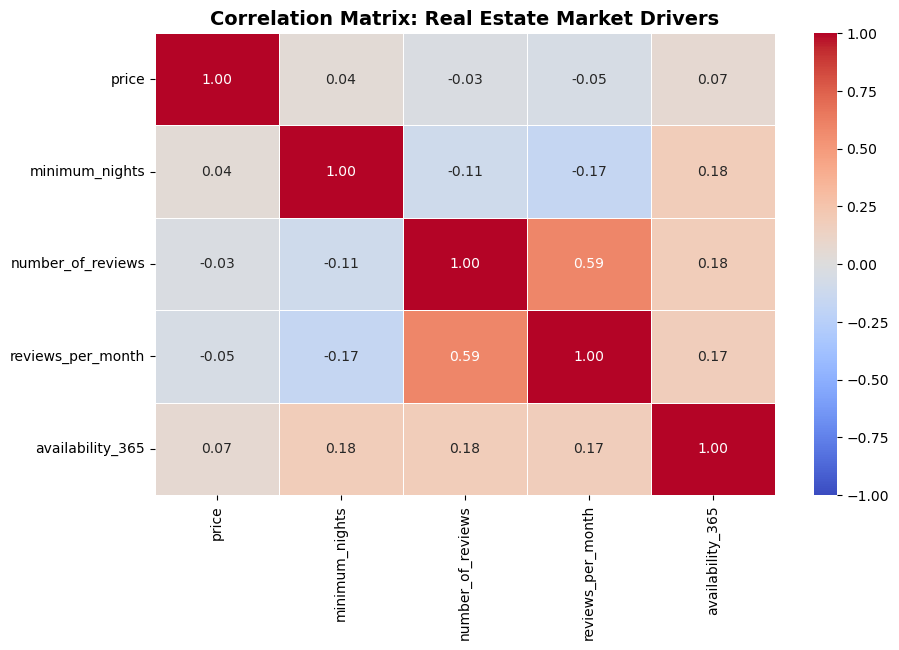

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("airbnb_cleaned.csv")

# ---------------------------------------------------------
# Heatmap: Real Estate Metrics Correlation
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']

# Enhanced visualization styling for presentations
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix: Real Estate Market Drivers", fontsize=14, fontweight='bold')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_31828\3596210580.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood_group', y='price', data=df, palette='magma', order=order_price, errorbar=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_31828\3596210580.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood_group', y='number_of_reviews', data=df, palette='viridis', order=order_reviews, errorbar=None)


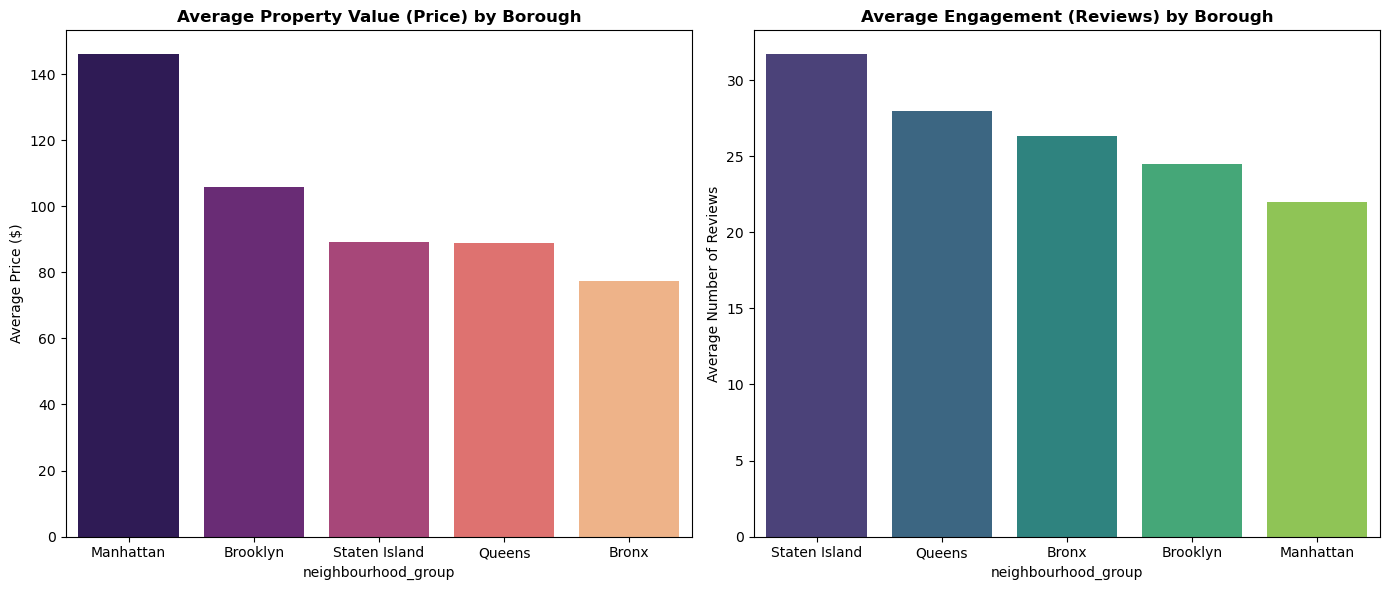

In [3]:
# ---------------------------------------------------------
# Real Estate Valuation & Popularity by Borough
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Sorting to make the chart more analytical
order_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).index
sns.barplot(x='neighbourhood_group', y='price', data=df, palette='magma', order=order_price, errorbar=None)
plt.title("Average Property Value (Price) by Borough", fontweight='bold')
plt.ylabel("Average Price ($)")

plt.subplot(1, 2, 2)
order_reviews = df.groupby('neighbourhood_group')['number_of_reviews'].mean().sort_values(ascending=False).index
sns.barplot(x='neighbourhood_group', y='number_of_reviews', data=df, palette='viridis', order=order_reviews, errorbar=None)
plt.title("Average Engagement (Reviews) by Borough", fontweight='bold')
plt.ylabel("Average Number of Reviews")

plt.tight_layout()
plt.show()

In [4]:
# --- STEP 4: Strategic Real Estate Recommendations ---

# 1. Calculate Context-Aware Benchmarks
# Comparing properties to their specific neighborhood market instead of global average
neighborhood_avg = df.groupby('neighbourhood_group')['price'].transform('mean')
avg_reviews = df['reviews_per_month'].mean()

# 2. Add Occupancy Score KPI for Dashboard visualization
df['occupancy_score'] = (1 - (df['availability_365'] / 365)) * 100

# 3. Advanced Recommendation Logic
def get_recommendation(row):
    # Case A: Overpriced for its specific market with low engagement
    if row['price'] > (neighborhood_avg.loc[row.name] * 1.2) and row['reviews_per_month'] < avg_reviews:
        return "Lower price to increase bookings"
    
    # Case B: High entry barrier for tenants
    elif row['minimum_nights'] > 3:
        return "Reduce minimum nights for more traffic"
    
    # Case C: Good price but low engagement (Content/Marketing issue)
    elif row['price'] <= neighborhood_avg.loc[row.name] and row['reviews_per_month'] < (avg_reviews * 0.5):
        return "Improve listing description and photos"
    
    # Case D: Excellent Real Estate Performance
    elif row['reviews_per_month'] >= avg_reviews:
        return "Keep current strategy - High Performance"
    
    # Case E: Default
    else:
        return "Promote listing via social media"

# 4. Apply the logic and create the new column
df['final_recommendation'] = df.apply(get_recommendation, axis=1)

# 5. Export the results to a new file ready for Power BI
print("Summary of Strategic Recommendations:")
print(df['final_recommendation'].value_counts())

df.to_csv("airbnb_recommendations_report.csv", index=False)
print("\n✅ Success: Final report 'airbnb_recommendations_report.csv' is ready!")

Summary of Strategic Recommendations:
final_recommendation
Keep current strategy - High Performance    12369
Reduce minimum nights for more traffic      11309
Lower price to increase bookings             9266
Improve listing description and photos       8364
Promote listing via social media             4532
Name: count, dtype: int64

✅ Success: Final report 'airbnb_recommendations_report.csv' is ready!
